# Task 2: Multi-Class Classification using KNN from Scratch — CIFAR-10

This notebook follows Task 2 of Assignment 1.

**Important:** The KNN classifier itself is implemented from scratch. We do not use `sklearn.neighbors.KNeighborsClassifier`, PyTorch KNN, or another pre-built KNN model.

CIFAR-10 contains 50,000 training images and 10,000 test images, with 10 classes. Because brute-force KNN on the complete dataset is computationally very expensive in Google Colab, this notebook provides a configurable subset size for experimentation. You can increase the sample sizes if your Colab runtime has enough RAM/CPU.

## 1. Import Required Libraries

In [2]:
import os
import tarfile
import urllib.request
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Download CIFAR-10

We download the official CIFAR-10 Python archive directly and extract it in Colab.

The dataset has 10 classes:
- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

In [3]:
url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
archive_path = "/content/cifar-10-python.tar.gz"
extract_path = "/content"

if not os.path.exists("/content/cifar-10-batches-py"):
    print("Downloading CIFAR-10...")
    urllib.request.urlretrieve(url, archive_path)

    print("Extracting CIFAR-10...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=extract_path)

    print("Download and extraction completed.")
else:
    print("CIFAR-10 is already available.")

Extracting CIFAR-10...


/tmp/ipykernel_1577/1540208283.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Download and extraction completed.


## 3. Load CIFAR-10 Batches

In [4]:
data_dir = "/content/cifar-10-batches-py"

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def load_batch(file_path):
    with open(file_path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")

    X = batch[b"data"]
    y = np.array(batch[b"labels"])

    return X, y

X_train_list = []
y_train_list = []

for i in range(1, 6):
    X_batch, y_batch = load_batch(
        os.path.join(data_dir, f"data_batch_{i}")
    )
    X_train_list.append(X_batch)
    y_train_list.append(y_batch)

X_train_full = np.vstack(X_train_list)
y_train_full = np.concatenate(y_train_list)

X_test_full, y_test_full = load_batch(
    os.path.join(data_dir, "test_batch")
)

print("Full training data:", X_train_full.shape)
print("Full training labels:", y_train_full.shape)
print("Full testing data:", X_test_full.shape)
print("Full testing labels:", y_test_full.shape)

Full training data: (50000, 3072)
Full training labels: (50000,)
Full testing data: (10000, 3072)
Full testing labels: (10000,)


## 4. Understand the Image Shape

Each CIFAR-10 image is `32 × 32` pixels with 3 color channels (RGB).

Therefore:

`32 × 32 × 3 = 3072`

features are stored for every image.

The raw CIFAR-10 batch stores these 3072 values as a one-dimensional vector.

Number of features per image: 3072
Number of classes: 10


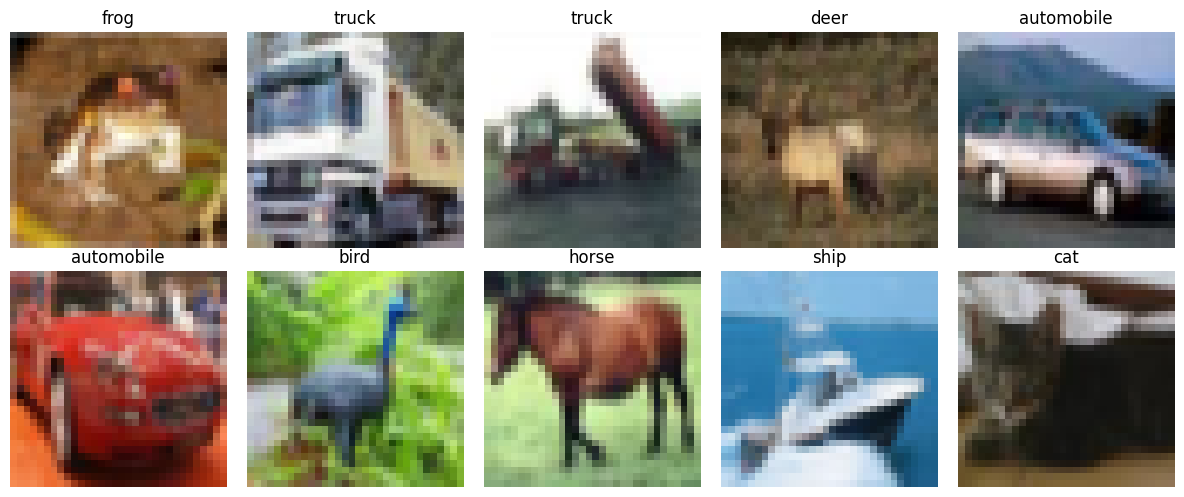

In [5]:
print("Number of features per image:", X_train_full.shape[1])
print("Number of classes:", len(class_names))

# Display a few images
images = X_train_full[:10].reshape(-1, 3, 32, 32)
images = images.transpose(0, 2, 3, 1)

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Select Data for KNN Experimentation

A complete brute-force KNN experiment with 50,000 training images and 10,000 test images is extremely expensive because distances have to be calculated between test and training images.

The variables below let you control the computational cost.

**Recommended first run in Colab:**
- 5,000 training images
- 1,000 testing images

After confirming that everything works, increase these values if your runtime allows it.

In [6]:
N_TRAIN = 5000
N_TEST = 1000

rng = np.random.default_rng(42)

train_indices = rng.choice(
    len(X_train_full),
    size=N_TRAIN,
    replace=False
)

test_indices = rng.choice(
    len(X_test_full),
    size=N_TEST,
    replace=False
)

X_train = X_train_full[train_indices].astype(np.float32)
y_train = y_train_full[train_indices]

X_test = X_test_full[test_indices].astype(np.float32)
y_test = y_test_full[test_indices]

print("Selected training data:", X_train.shape)
print("Selected testing data:", X_test.shape)

Selected training data: (5000, 3072)
Selected testing data: (1000, 3072)


## 6. Normalize Pixel Values

The original pixel values range from 0 to 255.

We divide by 255 so that every pixel lies between 0 and 1.

This is especially useful for distance calculations.

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## 7. Distance Functions From Scratch

We implement all five distance/similarity measures required by the assignment:

1. Euclidean distance
2. Manhattan distance
3. Minkowski distance
4. Cosine distance
5. Hamming distance

For KNN, smaller distance means that two observations are more similar.

For cosine similarity, a larger similarity means more similar, so we convert it to cosine distance:

`Cosine distance = 1 - Cosine similarity`

In [8]:
def euclidean_batch(x, X):
    # Euclidean distance:
    # sqrt(sum((x_i - X_i)^2))
    return np.sqrt(np.sum((X - x) ** 2, axis=1))


def manhattan_batch(x, X):
    # Manhattan distance:
    # sum(|x_i - X_i|)
    return np.sum(np.abs(X - x), axis=1)


def minkowski_batch(x, X, p=3):
    # Minkowski distance:
    # (sum(|x_i - X_i|^p))^(1/p)
    return np.sum(np.abs(X - x) ** p, axis=1) ** (1 / p)


def cosine_batch(x, X):
    # Cosine distance = 1 - cosine similarity
    numerator = X @ x
    denominator = np.linalg.norm(X, axis=1) * np.linalg.norm(x)

    denominator = np.where(denominator == 0, 1e-12, denominator)

    similarity = numerator / denominator
    return 1 - similarity


def hamming_batch(x, X):
    # Hamming distance is the fraction of coordinates that differ.
    # Pixels are integer-valued originally, so comparison is performed
    # after converting back to the 0-255 scale.
    x_pixels = np.rint(x * 255).astype(np.uint8)
    X_pixels = np.rint(X * 255).astype(np.uint8)

    return np.mean(X_pixels != x_pixels, axis=1)

## 8. Check the Distance Functions

Before running KNN, we test that every distance function returns a valid distance.

In [9]:
x1 = X_train[0]
x2 = X_train[1]

print("Euclidean :", euclidean_batch(x1, X_train[:2]))
print("Manhattan :", manhattan_batch(x1, X_train[:2]))
print("Minkowski :", minkowski_batch(x1, X_train[:2]))
print("Cosine    :", cosine_batch(x1, X_train[:2]))
print("Hamming   :", hamming_batch(x1, X_train[:2]))

Euclidean : [ 0.       18.348524]
Manhattan : [  0.     814.2667]
Minkowski : [0.       5.487921]
Cosine    : [3.5762787e-07 2.0925152e-01]
Hamming   : [0.         0.99446615]


## 9. KNN Prediction From Scratch

For each test image:

1. Calculate its distance from every training image.
2. Sort the distances.
3. Select the `K` nearest training images.
4. Look at their class labels.
5. Select the class occurring most frequently.

No pre-built KNN classifier is used.

In [10]:
def get_distances(x, X_train, metric):
    if metric == "euclidean":
        return euclidean_batch(x, X_train)

    elif metric == "manhattan":
        return manhattan_batch(x, X_train)

    elif metric == "minkowski":
        return minkowski_batch(x, X_train, p=3)

    elif metric == "cosine":
        return cosine_batch(x, X_train)

    elif metric == "hamming":
        return hamming_batch(x, X_train)

    else:
        raise ValueError("Unknown distance metric")


def knn_predict_one(x, X_train, y_train, k, metric):
    distances = get_distances(x, X_train, metric)

    # Get indices of the K smallest distances.
    nearest_indices = np.argpartition(distances, k - 1)[:k]

    nearest_labels = y_train[nearest_indices]

    # Majority voting.
    prediction = Counter(nearest_labels).most_common(1)[0][0]

    return prediction


def knn_predict(X_train, y_train, X_test, k, metric):
    predictions = []

    for i, x in enumerate(X_test):
        prediction = knn_predict_one(
            x, X_train, y_train, k, metric
        )
        predictions.append(prediction)

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(X_test)} test images")

    return np.array(predictions)

## 10. Accuracy Function

In [11]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

print("Accuracy function created.")

Accuracy function created.


## 11. Experiment With Different K Values and Distance Metrics

The assignment specifies:

`K = 3, 4, 9, 20, 47`

and the five required distance metrics.

To keep the first Colab run manageable, the experiment uses the selected subset defined above.

In [13]:
Ks = [3, 4, 9, 20, 47]

metrics = [
    "euclidean",
    "manhattan",
    "minkowski",
    "cosine",
    "hamming"
]

results = {}

for metric in metrics:
    results[metric] = []

    print("\n" + "=" * 60)
    print("Distance Metric:", metric)
    print("=" * 60)

    for k in Ks:
        print(f"\nRunning K = {k}")

        y_pred = knn_predict(
            X_train,
            y_train,
            X_test,
            k,
            metric
        )

        acc = accuracy_score(y_test, y_pred)
        results[metric].append(acc)

        print(f"Accuracy = {acc:.4f}")


Distance Metric: euclidean

Running K = 3
Processed 100/1000 test images
Processed 200/1000 test images
Processed 300/1000 test images
Processed 400/1000 test images
Processed 500/1000 test images
Processed 600/1000 test images
Processed 700/1000 test images
Processed 800/1000 test images
Processed 900/1000 test images
Processed 1000/1000 test images
Accuracy = 0.2850

Running K = 4
Processed 100/1000 test images
Processed 200/1000 test images
Processed 300/1000 test images
Processed 400/1000 test images
Processed 500/1000 test images
Processed 600/1000 test images
Processed 700/1000 test images
Processed 800/1000 test images
Processed 900/1000 test images
Processed 1000/1000 test images
Accuracy = 0.3000

Running K = 9
Processed 100/1000 test images
Processed 200/1000 test images
Processed 300/1000 test images
Processed 400/1000 test images
Processed 500/1000 test images
Processed 600/1000 test images
Processed 700/1000 test images
Processed 800/1000 test images
Processed 900/1000 te

## 12. Display Accuracy Results

In [14]:
results_df = pd.DataFrame(
    results,
    index=Ks
)

results_df.index.name = "K"

display(results_df)

,euclidean,manhattan,minkowski,cosine,hamming
K,,,,,
3,0.285,0.289,0.254,0.294,0.210
4,0.300,0.294,0.268,0.290,0.222
9,0.280,0.302,0.246,0.303,0.238
20,0.273,0.291,0.262,0.300,0.264
47,0.271,0.294,0.253,0.282,0.256


## 13. Plot K vs Accuracy for All Distance Metrics

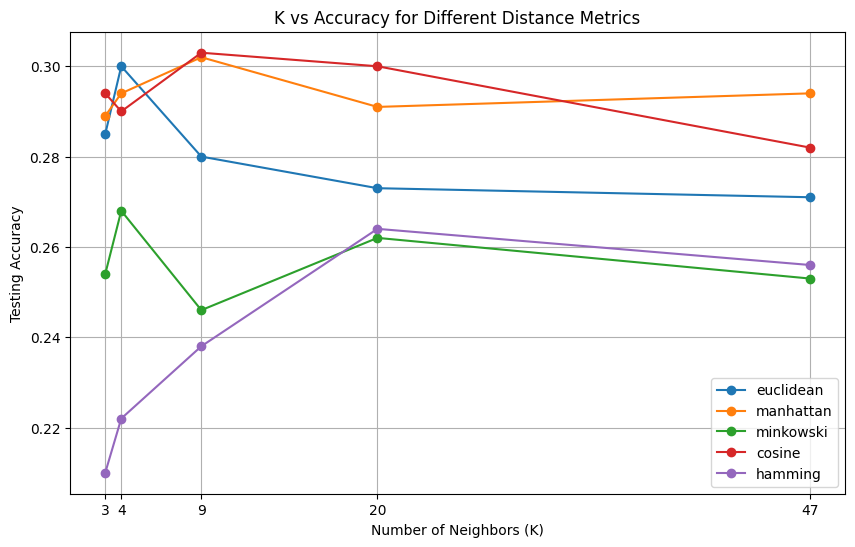

In [15]:
plt.figure(figsize=(10, 6))

for metric in metrics:
    plt.plot(
        Ks,
        results[metric],
        marker="o",
        label=metric
    )

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Testing Accuracy")
plt.title("K vs Accuracy for Different Distance Metrics")
plt.xticks(Ks)
plt.legend()
plt.grid(True)
plt.show()

## 14. Find the Best K and Distance Metric

We search through all experimental results and select the combination that gives the highest testing accuracy.

In [16]:
best_metric = None
best_k = None
best_accuracy = -1

for metric in metrics:
    for i, k in enumerate(Ks):
        current_accuracy = results[metric][i]

        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy
            best_metric = metric
            best_k = k

print("Best Distance Metric:", best_metric)
print("Best K:", best_k)
print("Best Testing Accuracy:", round(best_accuracy, 4))

Best Distance Metric: cosine
Best K: 9
Best Testing Accuracy: 0.303


## 15. Generate Predictions Using the Best Model

In [17]:
print("Running the best KNN configuration...")

best_predictions = knn_predict(
    X_train,
    y_train,
    X_test,
    best_k,
    best_metric
)

print("Prediction completed.")

Running the best KNN configuration...
Processed 100/1000 test images
Processed 200/1000 test images
Processed 300/1000 test images
Processed 400/1000 test images
Processed 500/1000 test images
Processed 600/1000 test images
Processed 700/1000 test images
Processed 800/1000 test images
Processed 900/1000 test images
Processed 1000/1000 test images
Prediction completed.


## 16. Confusion Matrix From Scratch

The confusion matrix for 10-class classification is a `10 × 10` matrix.

- Row = actual class
- Column = predicted class
- Diagonal values = correctly classified images

In [18]:
def confusion_matrix_multiclass(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)

    for actual, predicted in zip(y_true, y_pred):
        cm[actual, predicted] += 1

    return cm


cm = confusion_matrix_multiclass(
    y_test,
    best_predictions,
    len(class_names)
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

display(cm_df)

,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
airplane,40,1,5,3,3,1,2,2,36,0
automobile,8,10,6,2,6,6,4,2,36,2
bird,27,1,46,3,12,7,9,0,16,0
cat,13,1,21,15,10,17,7,1,10,2
deer,18,1,24,6,28,3,2,1,14,0
dog,11,0,14,11,12,36,5,1,10,0
frog,7,0,26,11,18,8,16,2,9,0
horse,17,0,17,4,17,7,7,26,13,1
ship,21,1,3,1,2,5,3,0,72,1
truck,11,5,4,3,5,3,7,3,40,14


## 17. Visualize the Confusion Matrix

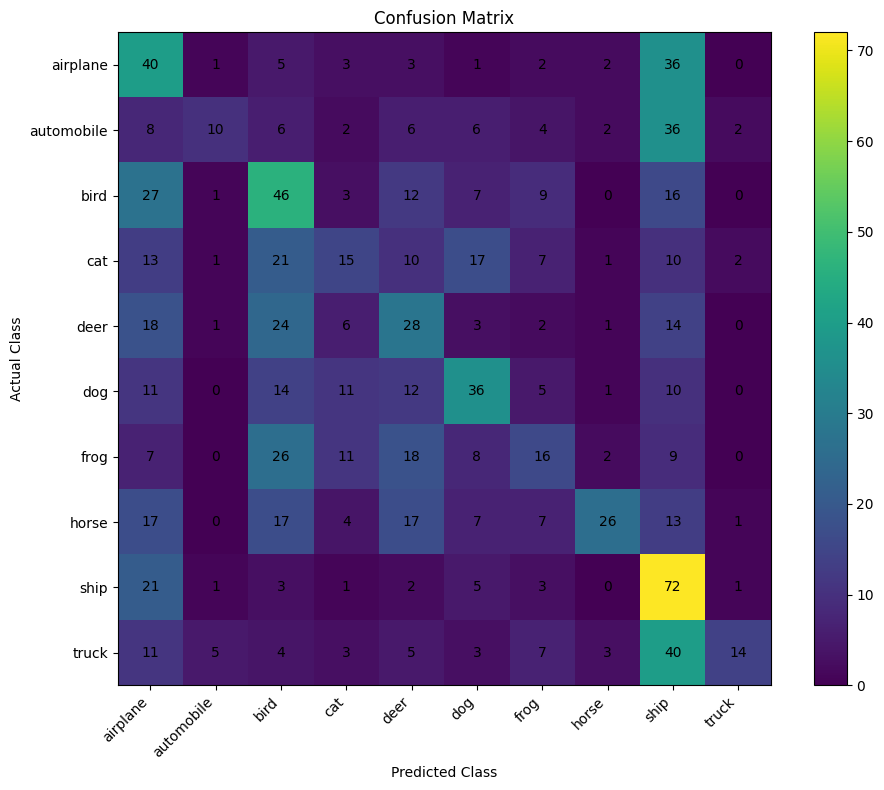

In [19]:
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## 18. Precision and Recall for Each Class

For every class:

**Precision**

`TP / (TP + FP)`

It tells us: among the images predicted as a particular class, how many were actually that class?

**Recall**

`TP / (TP + FN)`

It tells us: among all actual images of a particular class, how many did the model correctly identify?

In [20]:
precision = []
recall = []

for i in range(len(class_names)):
    tp = cm[i, i]

    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp

    if tp + fp == 0:
        p = 0
    else:
        p = tp / (tp + fp)

    if tp + fn == 0:
        r = 0
    else:
        r = tp / (tp + fn)

    precision.append(p)
    recall.append(r)

metrics_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall
})

display(metrics_df)

print("Macro Precision:", np.mean(precision))
print("Macro Recall:", np.mean(recall))

,Class,Precision,Recall
0,airplane,0.231214,0.430108
1,automobile,0.500000,0.121951
2,bird,0.277108,0.380165
3,cat,0.254237,0.154639
4,deer,0.247788,0.288660
5,dog,0.387097,0.360000
6,frog,0.258065,0.164948
7,horse,0.684211,0.238532
8,ship,0.281250,0.660550
9,truck,0.700000,0.147368


Macro Precision: 0.38209690219607423
Macro Recall: 0.2946922448190497


## 19. Compare Distance Metrics

This table makes it easier to identify which distance metric performs best for each value of K.

In [21]:
comparison = results_df.copy()

display(comparison)

print("\nBest result for each metric:")

for metric in metrics:
    metric_best = max(results[metric])
    metric_best_k = Ks[np.argmax(results[metric])]

    print(
        f"{metric:12s} -> "
        f"K = {metric_best_k}, "
        f"Accuracy = {metric_best:.4f}"
    )

,euclidean,manhattan,minkowski,cosine,hamming
K,,,,,
3,0.285,0.289,0.254,0.294,0.210
4,0.300,0.294,0.268,0.290,0.222
9,0.280,0.302,0.246,0.303,0.238
20,0.273,0.291,0.262,0.300,0.264
47,0.271,0.294,0.253,0.282,0.256



Best result for each metric:
euclidean    -> K = 4, Accuracy = 0.3000
manhattan    -> K = 9, Accuracy = 0.3020
minkowski    -> K = 4, Accuracy = 0.2680
cosine       -> K = 9, Accuracy = 0.3030
hamming      -> K = 20, Accuracy = 0.2640


## 20. Example Predictions

We display a few test images together with their actual and predicted classes.

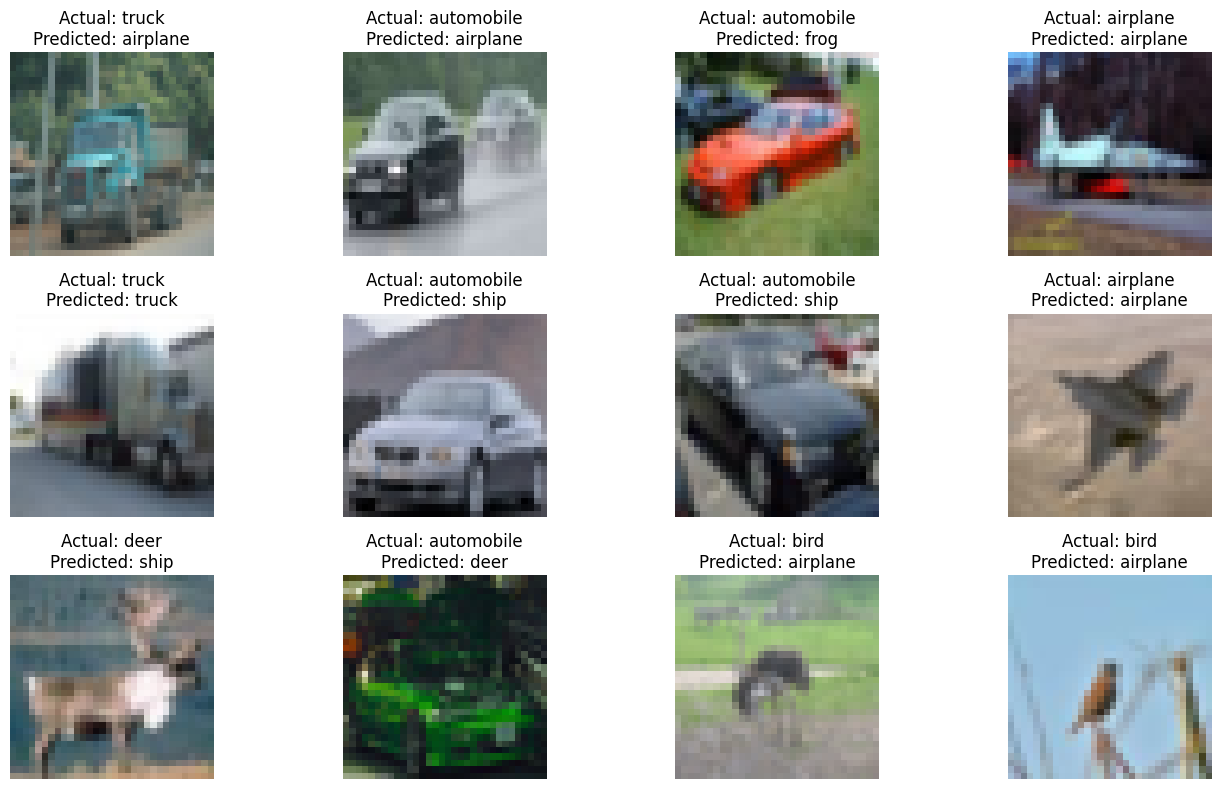

In [22]:
num_examples = 12

# Convert flattened normalized vectors back into images.
example_images = X_test[:num_examples] * 255
example_images = example_images.astype(np.uint8)

example_images = example_images.reshape(
    -1, 3, 32, 32
).transpose(0, 2, 3, 1)

plt.figure(figsize=(14, 8))

for i in range(num_examples):
    plt.subplot(3, 4, i + 1)
    plt.imshow(example_images[i])

    actual = class_names[y_test[i]]
    predicted = class_names[best_predictions[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 21. Observations / Inference

Run the notebook first and then complete the following observations using the actual values printed by your experiment.

1. The best K is **_____**.
2. The best distance metric is **_____**.
3. The highest testing accuracy obtained is **_____**.
4. Increasing K does not necessarily increase accuracy because a very large neighborhood can include samples from other classes.
5. Different distance metrics measure similarity differently, so their performance can vary.
6. CIFAR-10 is much more difficult than the binary breast-cancer dataset because the images contain high-dimensional visual information and ten different classes.
7. Brute-force KNN is computationally expensive because every test image must be compared with many training images.
8. The confusion matrix shows which CIFAR-10 classes are most frequently confused with one another.

## 22. Important Computational Note

The assignment describes the complete CIFAR-10 dataset as 50,000 training images and 10,000 test images.

A pure brute-force KNN implementation requires a very large number of distance calculations. Therefore, the notebook uses:

```python
N_TRAIN = 5000
N_TEST = 1000
```

for a practical Colab experiment.

If your instructor requires the complete dataset, change these to:

```python
N_TRAIN = 50000
N_TEST = 10000
```

However, the complete brute-force experiment can be extremely slow and may exceed Colab memory/time limits.

The KNN algorithm itself remains implemented from scratch.

## 23. Final Result

Use the output from Section 14 to report:

- **Best K:** value printed by the notebook
- **Best Distance Metric:** value printed by the notebook
- **Best Accuracy:** value printed by the notebook
- **Precision:** see Section 18
- **Recall:** see Section 18
- **Confusion Matrix:** see Sections 16–17

Do not manually invent these values; report the values obtained from your actual run.